# Drilling Sensor Data — Unsupervised Learning

**Dataset:** XAI Drilling Dataset (20,000 rows, sensor readings from a drilling process)

**Goal:** Use unsupervised learning (no labels shown to the model) to discover natural groupings
in the drilling sensor data, using:
1. **K-Means Clustering**
2. **PCA** (Principal Component Analysis) for visualization
3. A check: do the clusters we find on our own actually line up with real failures?

This is the same dataset used for yesterday's supervised task, but today we deliberately
**ignore the `Main Failure` label while training** — we only use it at the very end, to see if
the patterns unsupervised learning finds on its own are meaningful.


## 1. Load and explore the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("XAI_Drilling_Dataset.csv")
print(df.shape)
df.head()


(20000, 15)


,ID,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Process Time [sec],Main Failure,BEF,CCF,FWF,WDF
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


## 2. Preprocessing

For clustering we only use the **numeric sensor features** — no target labels at all.
We also one-hot encode `Material` and `Drill Bit Type` since they may still be useful groupings,
but we deliberately drop `Main Failure`, `BEF`, `CCF`, `FWF`, `WDF` and `ID` from the features used
for clustering (we keep `Main Failure` aside only to check our results afterwards).

In [3]:
features = df.drop(columns=['ID', 'Main Failure', 'BEF', 'CCF', 'FWF', 'WDF'])
features = pd.get_dummies(features, columns=['Material', 'Drill Bit Type'], drop_first=True)
features.head()


,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Process Time [sec],Material_N,Material_P,Drill Bit Type_N,Drill Bit Type_W
0,29.92,794,0.218,173,194.87,75,19.26,True,False,False,True
1,29.85,792,0.241,191,214.71,75,19.55,True,False,False,True
2,22.85,606,0.183,111,95.68,50,36.16,False,True,True,False
3,29.60,785,0.236,237,206.93,75,21.22,True,False,False,True
4,17.43,462,0.246,114,74.85,50,33.56,False,False,False,False


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (20000, 11)


Scaling is important for K-Means because it uses distance — without scaling, a feature like
`Spindle speed [1/min]` (values in the hundreds) would dominate a feature like `Cooling [%]`
(values 0-100) purely because of its bigger numbers, not because it's actually more important.

## 3. Finding the right number of clusters (Elbow Method + Silhouette Score)

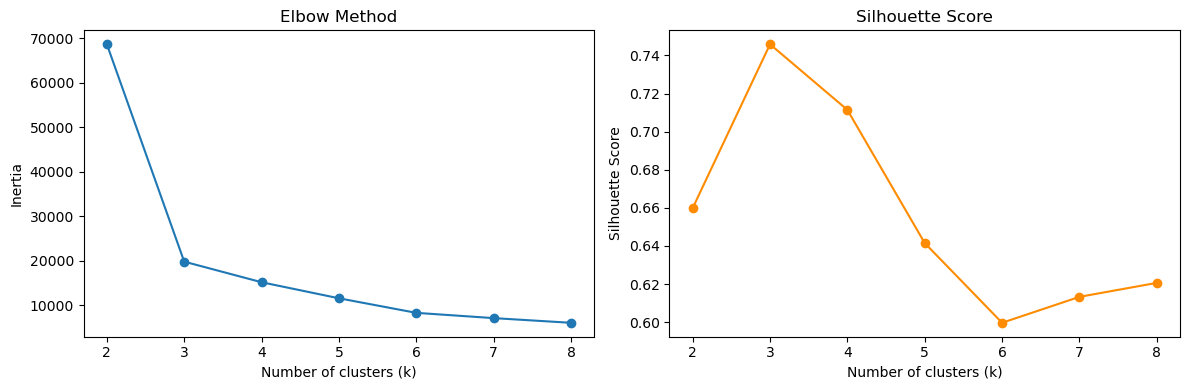

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


**How to read this:**
- The **Elbow plot** shows inertia (how tight the clusters are) dropping as k increases — we look
  for the point where adding more clusters stops giving a big improvement (the "elbow").
- The **Silhouette Score** (closer to 1 is better) tells us how well-separated the clusters are.

Based on the plots above, we'll pick k=3, which also happens to line up nicely with the 3 material
types and 3 drill bit types in the raw data — a good sanity check.

## 4. K-Means Clustering

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'].value_counts().sort_index()


Cluster
0    6674
1    6652
2    6674
Name: count, dtype: int64

In [9]:
cluster_summary = df.groupby('Cluster')[
    ['Cutting speed vc [m/min]', 'Spindle speed n [1/min]', 'Feed f [mm/rev]',
     'Feed rate vf [mm/min]', 'Power Pc [kW]', 'Cooling [%]', 'Process Time [sec]']
].mean().round(2)

cluster_summary


,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Process Time [sec]
Cluster,,,,,,,
0,17.39,461.41,0.25,117.09,76.33,45.88,33.00
1,29.99,795.49,0.24,195.65,218.61,82.52,19.69
2,22.61,599.62,0.18,109.33,92.34,41.94,35.01


This gives us an average "sensor profile" for each cluster — a quick way to describe what kind of drilling conditions each group represents.

## 5. PCA for 2D Visualization

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum().round(3))


Explained variance ratio: [0.71334191 0.22253986]
Total variance captured by 2 components: 0.936


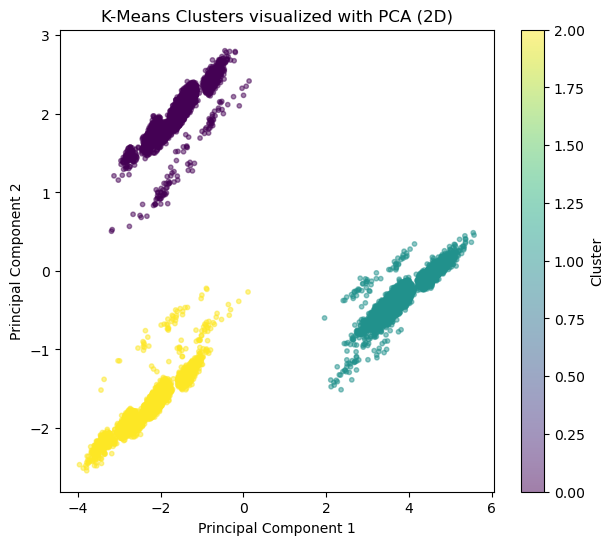

In [11]:
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.5, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters visualized with PCA (2D)")
plt.colorbar(scatter, label="Cluster")
plt.show()


## 6. Do the clusters relate to actual drilling failures?

Now — and only now — we bring back the real `Main Failure` label (which the clustering
algorithm never saw) to check whether the clusters it found on its own line up with anything
meaningful in the real world.

In [12]:
failure_rate_by_cluster = df.groupby('Cluster')['Main Failure'].mean().round(4) * 100
failure_rate_by_cluster.name = 'Failure rate (%)'
failure_rate_by_cluster


Cluster
0    4.35
1    5.49
2    5.18
Name: Failure rate (%), dtype: float64

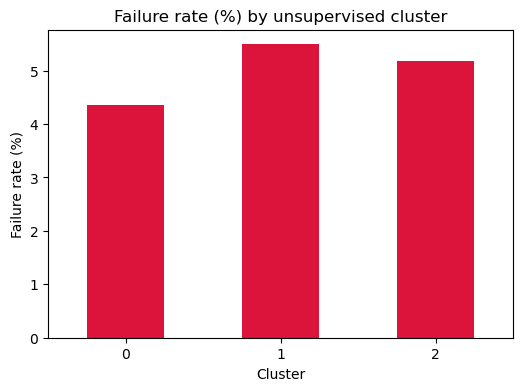

In [13]:
plt.figure(figsize=(6,4))
failure_rate_by_cluster.plot(kind='bar', color='crimson')
plt.title("Failure rate (%) by unsupervised cluster")
plt.xlabel("Cluster")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=0)
plt.show()


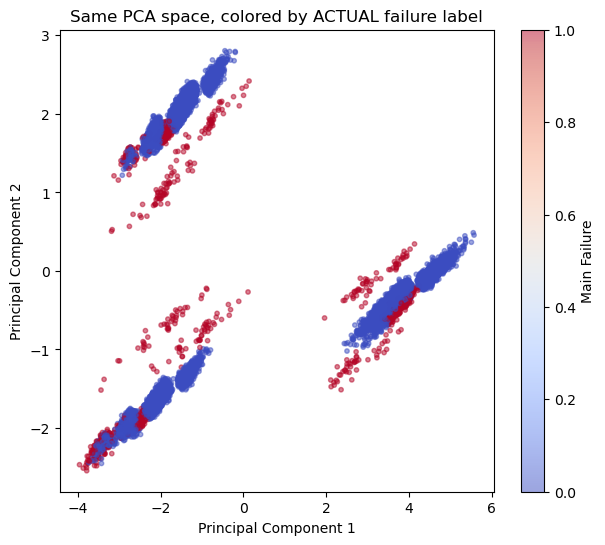

In [14]:
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Main Failure'], cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Same PCA space, colored by ACTUAL failure label")
plt.colorbar(scatter, label="Main Failure")
plt.show()
